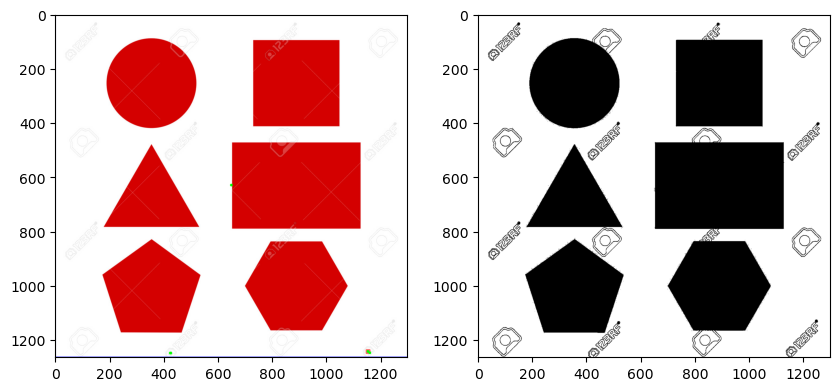

Contorno 1: Perímetro=41.79898953437805, Área=118.0, Vértices aproximados=9,centroide: cx:424 , cy:1249
Contorno 2: Perímetro=40.97056233882904, Área=117.0, Vértices aproximados=8,centroide: cx:1152 , cy:1243
Contorno 3: Perímetro=348.1320308446884, Área=341.0, Vértices aproximados=13,centroide: cx:426 , cy:1249
Contorno 4: Perímetro=145.9238796234131, Área=264.5, Vértices aproximados=11,centroide: cx:1152 , cy:1243
Contorno 5: Perímetro=232.87719762325287, Área=114.0, Vértices aproximados=10,centroide: cx:1159 , cy:1248
Contorno 6: Perímetro=5319.32084941864, Área=1638272.5, Vértices aproximados=4,centroide: cx:649 , cy:630


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = cv2.imread('./figuras.jpg')
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(gray, 247, 255, cv2.THRESH_BINARY , cv2.THRESH_OTSU)
contorno, jeraquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areaa = []
vertices = []
centroides=[]

for i in range(len(contorno)):
    cont = contorno[i]
    M = cv2.moments(cont)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0
    area = cv2.contourArea(cont)
    perimetro = cv2.arcLength(cont, True)
    epsilon = 0.02 * perimetro  
    vertice = cv2.approxPolyDP(cont, epsilon, True) 

    perimetros.append(perimetro)
    areaa.append(area)
    centroides.append(f'centroide: cx:{cx} , cy:{cy}')

    vertices.append(len(vertice))

    cv2.circle(imagen, (cx, cy), 5, (0, 255, 0), -1)
    x, y, w, h = cv2.boundingRect(cont)
    if len(vertice)==3:
        cv2.rectangle(imagen, (x, y), (x + w, y + h), (255, 100, 255), 3) #triangulo
    
    if len(vertice)==4:
        cv2.rectangle(imagen, (x, y), (x + w, y + h), (255, 100, 100), 3) #cuadrado
    
    if len(vertice)==8:
        cv2.rectangle(imagen, (x, y), (x + w, y + h), (100, 100, 255), 3) #circulo
    

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.imshow(bin, cmap='gray')

plt.show()

for i, (perimetro, area,centroide) in enumerate(zip(perimetros, areaa,centroides)):
    print(f'Contorno {i + 1}: Perímetro={perimetro}, Área={area}, Vértices aproximados={vertices[i]},{centroide}')